In [1]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [3]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


In [4]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.axis('off')

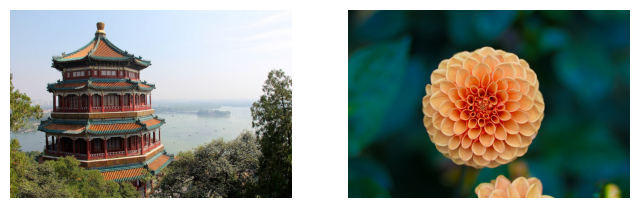

In [5]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [6]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

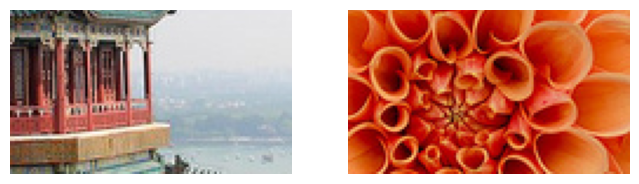

In [7]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])

plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [8]:
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=7
)
conv_layer.weight.shape

torch.Size([10, 3, 7, 7])

In [9]:
output = conv_layer(cropped_images)
output.shape

torch.Size([2, 10, 64, 114])

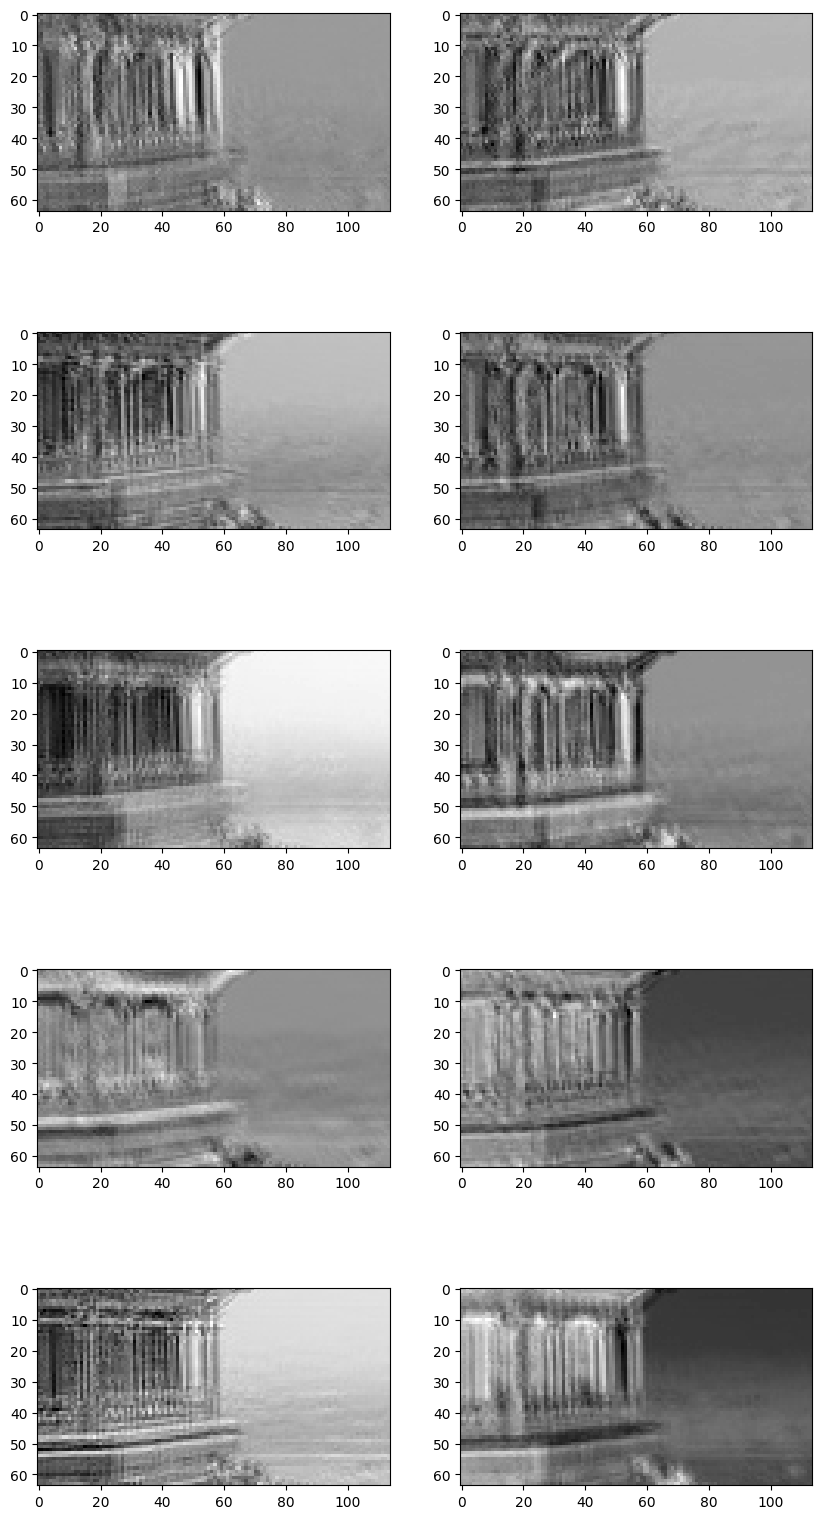

In [10]:
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

with torch.no_grad():
    output = conv_layer(cropped_images)

for ind, ax in enumerate(axs.flat):
    ax.imshow(output[0][ind], cmap='gray') 

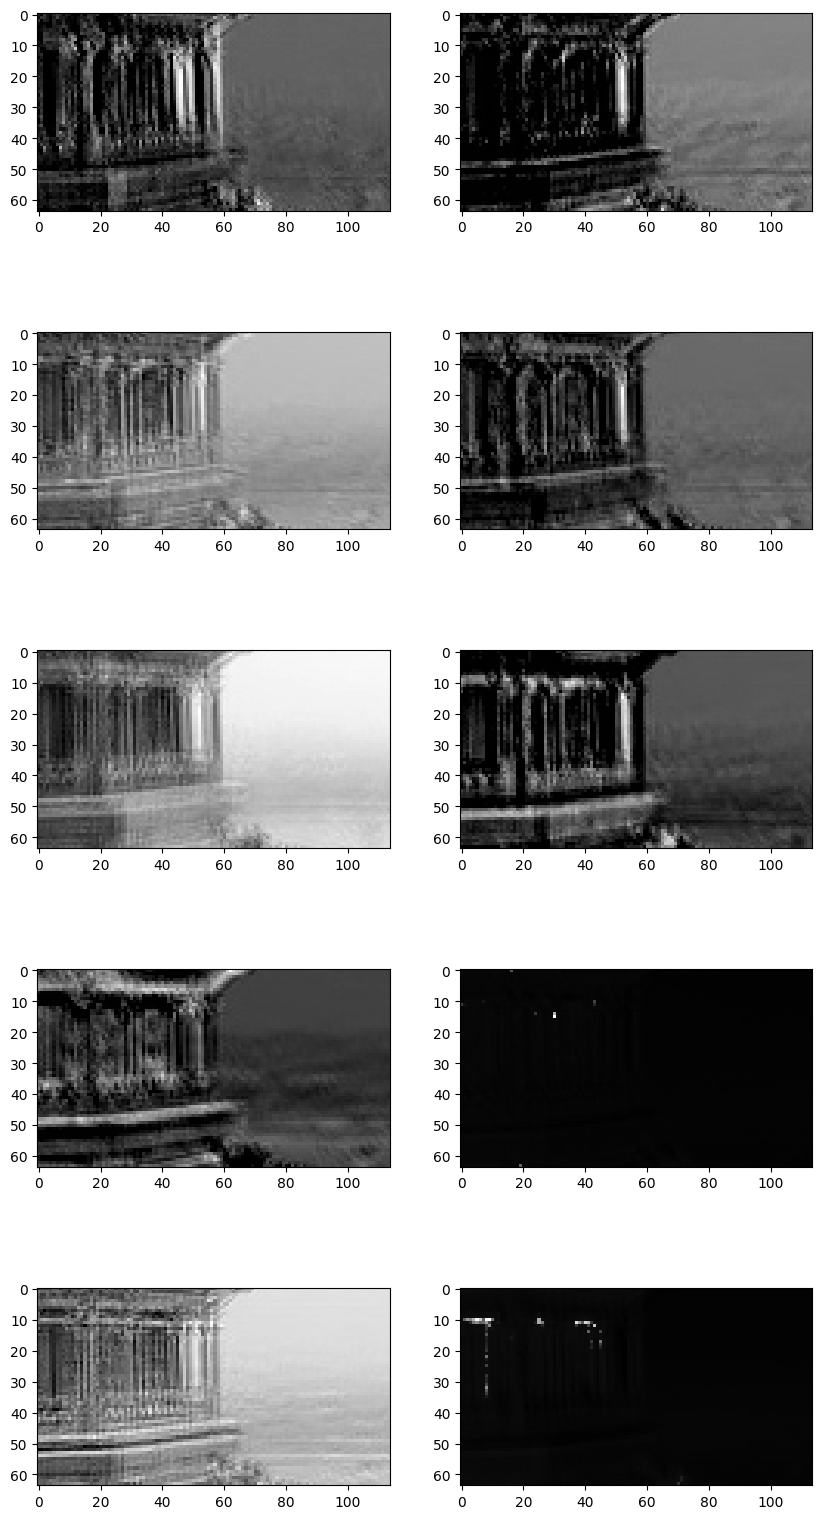

In [11]:
relu_layer = nn.LeakyReLU()
relu_output = relu_layer(output)

fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for ind, ax in enumerate(axs.flat):
    ax.imshow(relu_output[0][ind].detach(), cmap='gray')

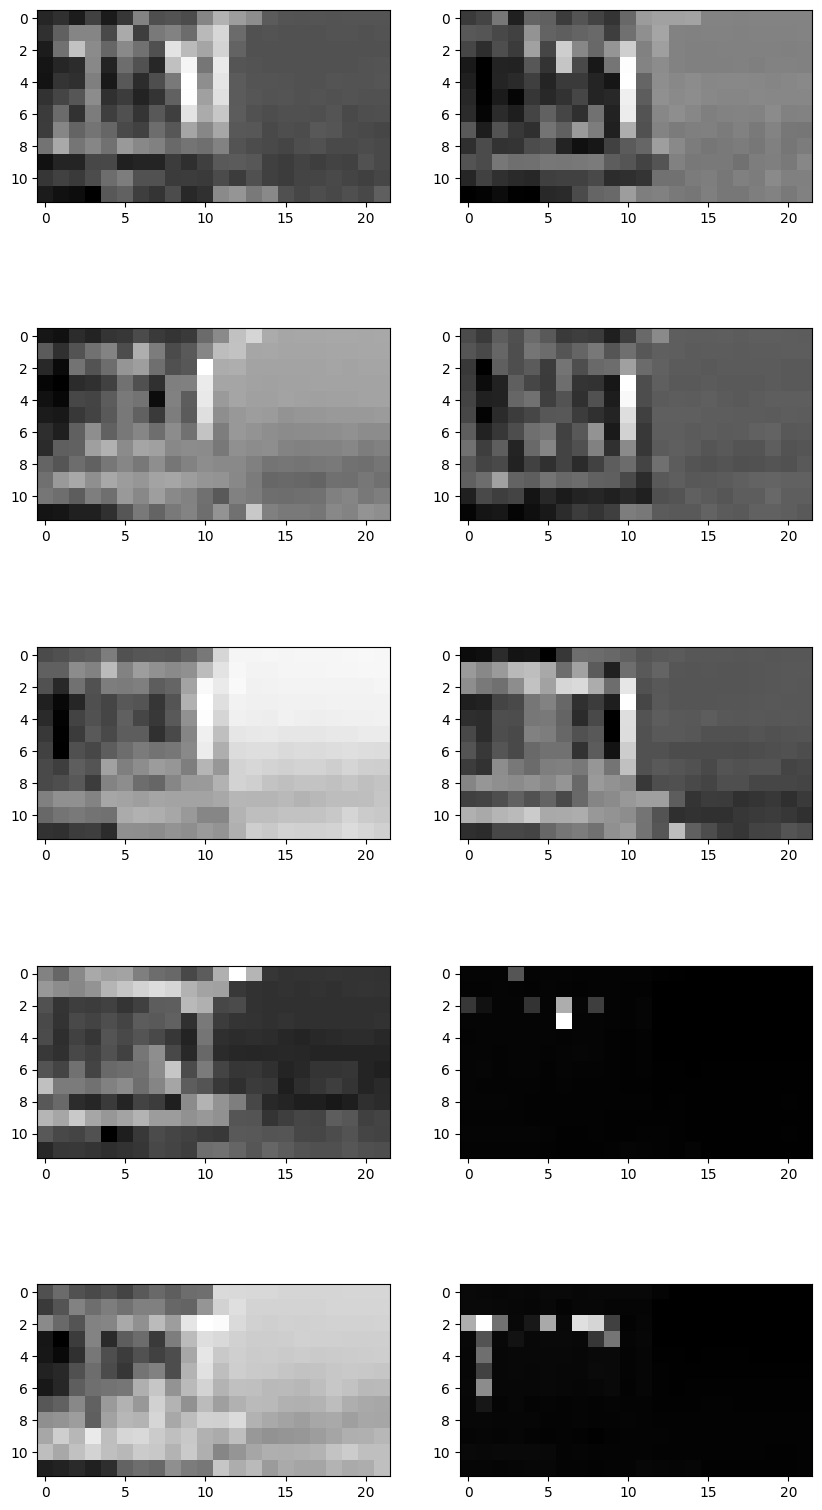

In [12]:
pooling_layer = nn.MaxPool2d(kernel_size=5)
pooling_ouput = pooling_layer(relu_output)

fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for ind, ax in enumerate(axs.flat):
    ax.imshow(pooling_ouput[0][ind].detach(), cmap='gray')

In [14]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=toTensor
)

test_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=toTensor
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55000, 5000])
train_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])
valid_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])

In [15]:
from torch.utils.data import DataLoader

torch.manual_seed(42)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [16]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

device

'cpu'

In [17]:
X, y = next(iter(train_loader))
X.shape

torch.Size([32, 1, 28, 28])

In [18]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding='same'),
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
    nn.LeakyReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3),
    nn.LeakyReLU(),
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3),
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=256, out_features=128),
    nn.LeakyReLU(),
    nn.Linear(in_features=128, out_features=64),
    nn.LeakyReLU(),
    nn.Linear(in_features=64, out_features=10)
).to(device)

In [21]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
history = train(
    model, 
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    warmup_scheduler=None,
    scheduler=None,
    patience=None,
    checkpoint_path='fashion_mnist_model.pt',
    clip_grad_norm=None,
    device=device
)

Epoch: 1/20, Train Loss: 2.309, Train Metric: 0.113, Valid Metric: 0.067, Time: 0.82s
	Checkpoint, valid metric: 0.067
Epoch: 2/20, Train Loss: 2.276, Train Metric: 0.12, Valid Metric: 0.2, Time: 0.84s
	Checkpoint, valid metric: 0.200
Epoch: 3/20, Train Loss: 2.128, Train Metric: 0.293, Valid Metric: 0.34, Time: 0.75s
	Checkpoint, valid metric: 0.340
Epoch: 4/20, Train Loss: 1.74, Train Metric: 0.32, Valid Metric: 0.447, Time: 0.77s
	Checkpoint, valid metric: 0.447
Epoch: 5/20, Train Loss: 1.45, Train Metric: 0.373, Valid Metric: 0.553, Time: 0.79s
	Checkpoint, valid metric: 0.553
Epoch: 6/20, Train Loss: 1.383, Train Metric: 0.427, Valid Metric: 0.52, Time: 0.81s
Epoch: 7/20, Train Loss: 1.186, Train Metric: 0.487, Valid Metric: 0.593, Time: 0.82s
	Checkpoint, valid metric: 0.593
Epoch: 8/20, Train Loss: 1.084, Train Metric: 0.6, Valid Metric: 0.56, Time: 0.78s
Epoch: 9/20, Train Loss: 1.02, Train Metric: 0.56, Valid Metric: 0.58, Time: 0.75s
Epoch: 10/20, Train Loss: 0.911, Train Met

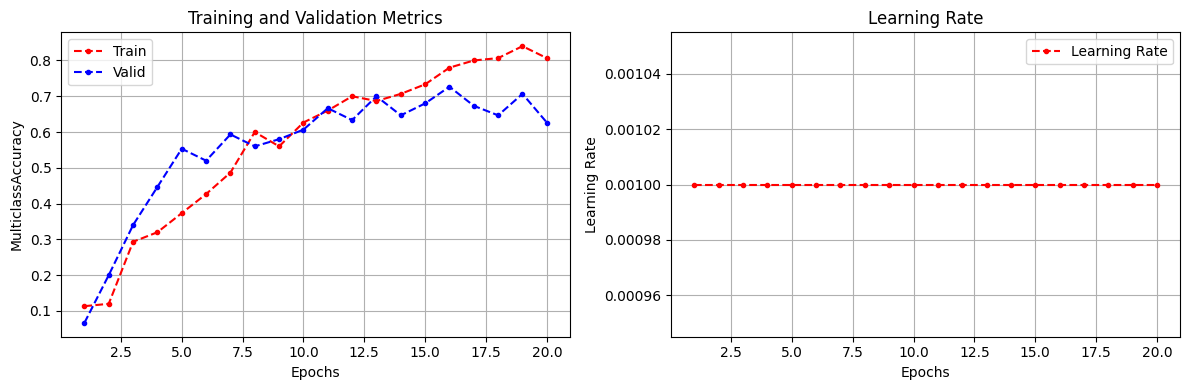

In [22]:
plot_history(history, metric)